[pglis] SSN updated: 726 points -> /Users/miguelreisorcinha/MY.AMS/PgLis/pglis/data_products/SSN.csv
[pglis] Dataset is up to date (version https://zenodo.org/records/19971913).
      time_unix                datetime_utc  \
0  8.204544e+08         1996-01-01T01:00:00   
1  8.230472e+08  1996-01-31T01:13:31.267606   
2  8.256400e+08  1996-03-01T01:27:02.535211   
3  8.282328e+08  1996-03-31T01:40:33.802817   
4  8.308256e+08  1996-04-30T02:54:05.070423   

   J[MeV/n^(-1) sr^(-1) s^(-1) m^(-2)]  
0                             1.149700  
1                             1.157382  
2                             1.167456  
3                             1.182920  
4                             1.203800  


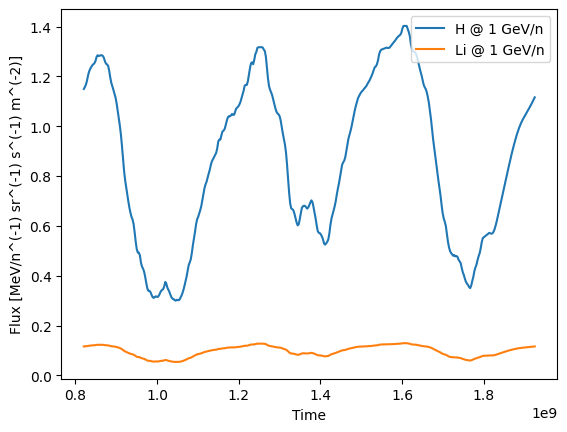

In [1]:
import pglis
import datetime
import pandas as pd
import matplotlib.pyplot as plt

# initialise
model = pglis.solar_mod()

# helper: date unix timestamp
def dt(year, month, day):
    return datetime.datetime(year, month, day, tzinfo=datetime.timezone.utc).timestamp()

# ── flux vs time
df = model.get_dataframe_flux_vs_time(
    Z=1,  # Hydrogen
    Ekn=1000.0,  # MeV/n
    t_start=dt(1996, 1, 1),
    t_end=dt(2031, 1, 1)
)
print(df.head())

df2 = model.get_dataframe_flux_vs_time(
    Z=2,  # Hydrogen
    Ekn=1000.0,  # MeV/n
    t_start=dt(1996, 1, 1),
    t_end=dt(2031, 1, 1)
)


fig, ax = plt.subplots()

ax.plot(df["time_unix"], df["J[MeV/n^(-1) sr^(-1) s^(-1) m^(-2)]"], label="H @ 1 GeV/n")
ax.plot(
    df2["time_unix"], df2["J[MeV/n^(-1) sr^(-1) s^(-1) m^(-2)]"], label="Li @ 1 GeV/n"
)
ax.set_xlabel("Time")
ax.set_ylabel("Flux [MeV/n^(-1) sr^(-1) s^(-1) m^(-2)]")


ax.legend()
plt.show()

In [2]:
import pglis, datetime

model = pglis.solar_mod()

t = datetime.datetime(2001, 6, 1).timestamp()

df = model.get_dataframe_flux_vs_energy(Z=1, time=t)

df.head()

,Ekn[MeV/n],J[MeV/n^(-1) sr^(-1) s^(-1) m^(-2)]
0,10.000000,0.017637
1,10.473709,0.018321
2,10.969858,0.019032
3,11.489510,0.019770
4,12.033778,0.020537


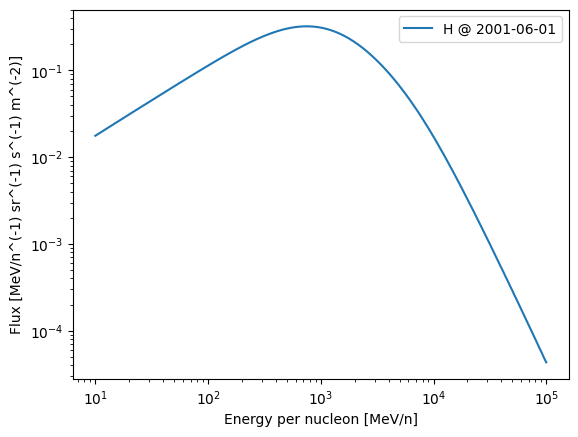

In [3]:
# plot
fig, ax = plt.subplots()
ax.plot(
    df["Ekn[MeV/n]"], df["J[MeV/n^(-1) sr^(-1) s^(-1) m^(-2)]"], label="H @ 2001-06-01"
)
ax.set_xlabel("Energy per nucleon [MeV/n]")
# log scale
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylabel("Flux [MeV/n^(-1) sr^(-1) s^(-1) m^(-2)]")
ax.legend()
plt.show()